### Лабораторна робота №4

##### Система прийняття рішень на основі нечітких правил. Варіант 1: Контролер кондиціонера

In [25]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Визначення вхідних та вихідних параметрів

In [26]:
# Вхідні параметри:
temperature = ctrl.Antecedent(np.arange(0, 41, 1), 'temperature')
humidity = ctrl.Antecedent(np.arange(0, 101, 1), 'humidity')
people_count = ctrl.Antecedent(np.arange(0, 11, 1), 'people_count')

# Вихідний параметр:
compressor_speed = ctrl.Consequent(np.arange(0, 101, 1), 'compressor_speed')

# Метод дефазифікації
compressor_speed.defuzzify_method = 'centroid'

# 2. Функції приналежності

In [27]:
temperature['cold'] = fuzz.zmf(temperature.universe, 14, 20)
temperature['comfortable'] = fuzz.trimf(temperature.universe, [18, 24, 30])
temperature['hot'] = fuzz.smf(temperature.universe, 26, 34)

humidity['low'] = fuzz.zmf(humidity.universe, 30, 45)
humidity['normal'] = fuzz.trimf(humidity.universe, [35, 55, 75])
humidity['high'] = fuzz.smf(humidity.universe, 65, 85)

people_count['few'] = fuzz.zmf(people_count.universe, 2, 4)
people_count['medium'] = fuzz.trimf(people_count.universe, [3, 5, 7])
people_count['many'] = fuzz.smf(people_count.universe, 6, 9)

compressor_speed['low'] = fuzz.trimf(compressor_speed.universe, [0, 0, 35])
compressor_speed['medium'] = fuzz.trimf(compressor_speed.universe, [25, 50, 75])
compressor_speed['high'] = fuzz.trimf(compressor_speed.universe, [65, 100, 100])

# 3. Візуалізація функцій приналежності в одному зображенні

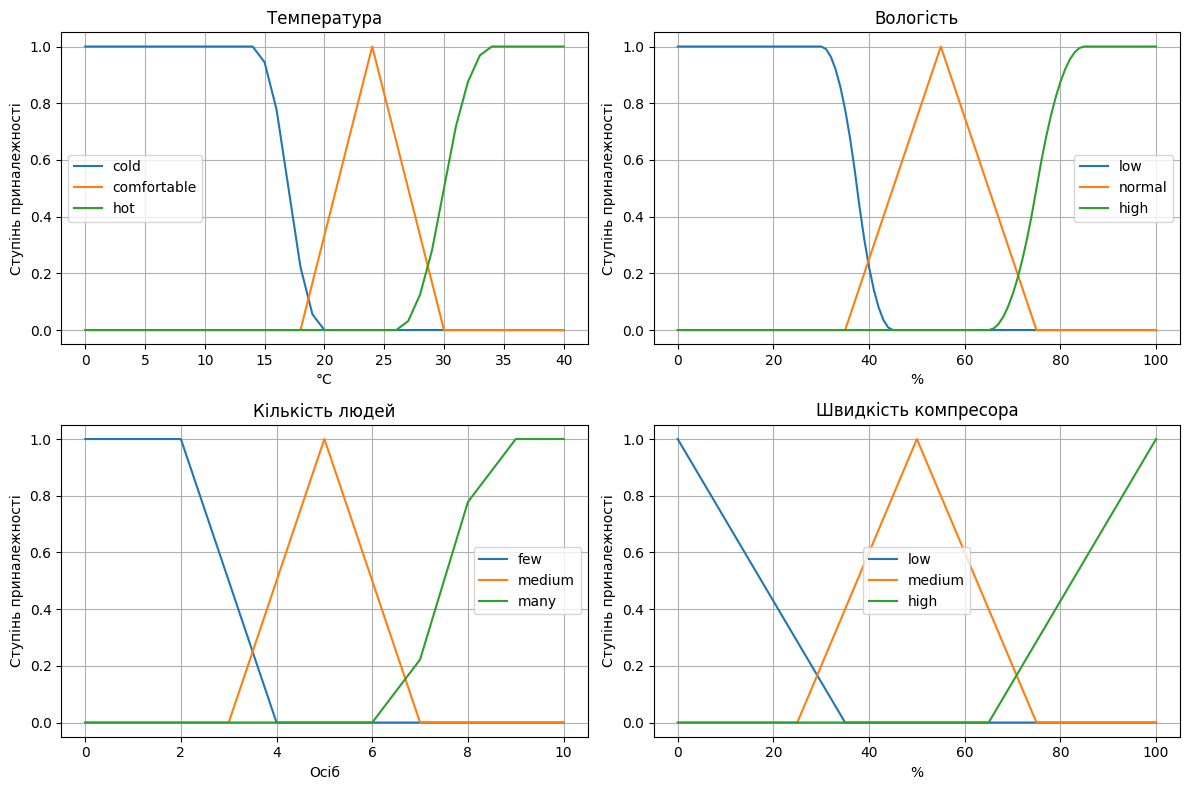

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(temperature.universe, temperature['cold'].mf, label='cold')
axes[0, 0].plot(temperature.universe, temperature['comfortable'].mf, label='comfortable')
axes[0, 0].plot(temperature.universe, temperature['hot'].mf, label='hot')
axes[0, 0].set_title("Температура")
axes[0, 0].set_xlabel("°C")
axes[0, 0].set_ylabel("Ступінь приналежності")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(humidity.universe, humidity['low'].mf, label='low')
axes[0, 1].plot(humidity.universe, humidity['normal'].mf, label='normal')
axes[0, 1].plot(humidity.universe, humidity['high'].mf, label='high')
axes[0, 1].set_title("Вологість")
axes[0, 1].set_xlabel("%")
axes[0, 1].set_ylabel("Ступінь приналежності")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(people_count.universe, people_count['few'].mf, label='few')
axes[1, 0].plot(people_count.universe, people_count['medium'].mf, label='medium')
axes[1, 0].plot(people_count.universe, people_count['many'].mf, label='many')
axes[1, 0].set_title("Кількість людей")
axes[1, 0].set_xlabel("Осіб")
axes[1, 0].set_ylabel("Ступінь приналежності")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(compressor_speed.universe, compressor_speed['low'].mf, label='low')
axes[1, 1].plot(compressor_speed.universe, compressor_speed['medium'].mf, label='medium')
axes[1, 1].plot(compressor_speed.universe, compressor_speed['high'].mf, label='high')
axes[1, 1].set_title("Швидкість компресора")
axes[1, 1].set_xlabel("%")
axes[1, 1].set_ylabel("Ступінь приналежності")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# 4. Формування нечітких правил

In [29]:
rule1 = ctrl.Rule(
    temperature['cold'] & humidity['low'] & people_count['few'],
    compressor_speed['low']
)

rule2 = ctrl.Rule(
    temperature['cold'] & humidity['normal'],
    compressor_speed['low']
)

rule3 = ctrl.Rule(
    temperature['cold'] & humidity['high'],
    compressor_speed['medium']
)

rule4 = ctrl.Rule(
    temperature['comfortable'] & humidity['low'] & people_count['few'],
    compressor_speed['low']
)

rule5 = ctrl.Rule(
    temperature['comfortable'] & humidity['normal'] & people_count['medium'],
    compressor_speed['medium']
)

rule6 = ctrl.Rule(
    temperature['comfortable'] & humidity['high'],
    compressor_speed['medium']
)

rule7 = ctrl.Rule(
    temperature['hot'] & humidity['low'],
    compressor_speed['medium']
)

rule8 = ctrl.Rule(
    temperature['hot'] & humidity['normal'],
    compressor_speed['high']
)

rule9 = ctrl.Rule(
    temperature['hot'] & humidity['high'],
    compressor_speed['high']
)

rule10 = ctrl.Rule(
    people_count['many'] & temperature['comfortable'],
    compressor_speed['medium']
)

rule11 = ctrl.Rule(
    people_count['many'] & temperature['hot'],
    compressor_speed['high']
)

rule12 = ctrl.Rule(
    humidity['high'] & people_count['many'],
    compressor_speed['high']
)

rule13 = ctrl.Rule(
    temperature['cold'] & people_count['medium'],
    compressor_speed['low']
)

rule14 = ctrl.Rule(
    temperature['cold'] & people_count['many'],
    compressor_speed['medium']
)

rule15 = ctrl.Rule(
    temperature['comfortable'] & people_count['few'],
    compressor_speed['low']
)

rule16 = ctrl.Rule(
    temperature['comfortable'] & people_count['many'],
    compressor_speed['medium']
)

rule17 = ctrl.Rule(
    temperature['hot'] & people_count['few'],
    compressor_speed['high']
)

rule18 = ctrl.Rule(
    temperature['hot'] & people_count['medium'],
    compressor_speed['high']
)

rule19 = ctrl.Rule(
    humidity['low'] & people_count['many'],
    compressor_speed['medium']
)

rule20 = ctrl.Rule(
    humidity['normal'] & people_count['many'],
    compressor_speed['medium']
)

rule21 = ctrl.Rule(
    temperature['comfortable'] & humidity['low'] & people_count['medium'],
    compressor_speed['low']
)

rule22 = ctrl.Rule(
    temperature['comfortable'] & humidity['normal'] & people_count['few'],
    compressor_speed['low']
)

rule23 = ctrl.Rule(
    temperature['hot'] & humidity['low'] & people_count['many'],
    compressor_speed['high']
)

# 5. Створення системи керування

In [30]:
air_conditioner_control = ctrl.ControlSystem([
    rule1, rule2, rule3,
    rule4, rule5, rule6,
    rule7, rule8, rule9,
    rule10, rule11, rule12,
    rule13, rule14, rule15, rule16,
    rule17, rule18, rule19, rule20,
    rule21, rule22, rule23
])

air_conditioner = ctrl.ControlSystemSimulation(air_conditioner_control)

# 6. Один тестовий приклад

Результат роботи системи:
Температура: 30 °C
Вологість: 70 %
Кількість людей: 5
Швидкість компресора: 86.39 %


c:\Users\angel\AppData\Local\Programs\Python\Python313\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


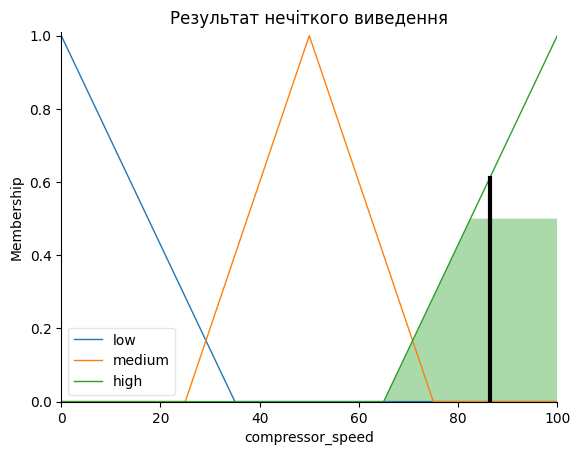

In [31]:
air_conditioner.input['temperature'] = 30
air_conditioner.input['humidity'] = 70
air_conditioner.input['people_count'] = 5

air_conditioner.compute()

print("Результат роботи системи:")
print("Температура:", 30, "°C")
print("Вологість:", 70, "%")
print("Кількість людей:", 5)
print("Швидкість компресора:", round(air_conditioner.output['compressor_speed'], 2), "%")

compressor_speed.view(sim=air_conditioner)
plt.title("Результат нечіткого виведення")
plt.show()

# 7. Тестування різних наборів вхідних параметрів

In [32]:
test_cases = [
    (16, 35, 1),
    (22, 50, 3),
    (25, 70, 5),
    (30, 60, 4),
    (34, 80, 7),
    (38, 90, 9)
]

results = []

for i, (temp, hum, people) in enumerate(test_cases, start=1):
    simulation = ctrl.ControlSystemSimulation(air_conditioner_control)
    
    simulation.input['temperature'] = temp
    simulation.input['humidity'] = hum
    simulation.input['people_count'] = people
    
    simulation.compute()
    
    if 'compressor_speed' in simulation.output:
        speed = round(simulation.output['compressor_speed'], 2)
    else:
        speed = None 
    
    results.append([i, temp, hum, people, speed])



print("Підсумкова таблиця результатів")
print("№ | Температура | Вологість | Людей | Швидкість компресора | ")
print("-" * 60)

for row in results:
    print(f"{row[0]} | {row[1]} °C       | {row[2]} %      | {row[3]}     | {row[4]} %")

Підсумкова таблиця результатів
№ | Температура | Вологість | Людей | Швидкість компресора | 
------------------------------------------------------------
1 | 16 °C       | 35 %      | 1     | 12.14 %
2 | 22 °C       | 50 %      | 3     | 13.61 %
3 | 25 °C       | 70 %      | 5     | 50.0 %
4 | 30 °C       | 60 %      | 4     | 86.39 %
5 | 34 °C       | 80 %      | 7     | 88.17 %
6 | 38 °C       | 90 %      | 9     | 88.33 %


# 8. Візуалізація залежності швидкості компресора від тестів

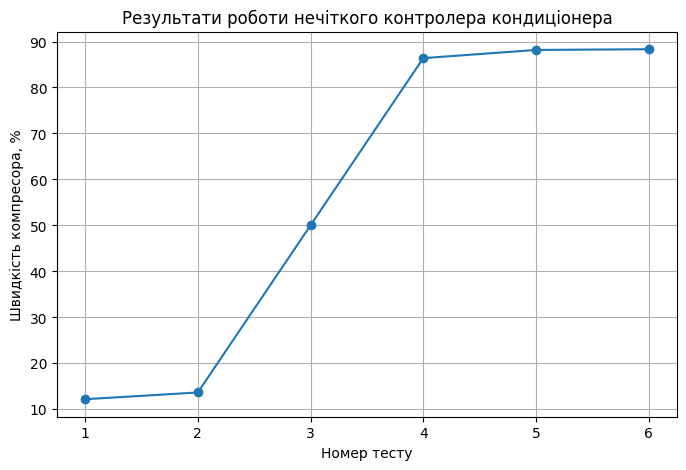

In [33]:
test_numbers = [row[0] for row in results]
speed_values = [row[4] for row in results]

plt.figure(figsize=(8, 5))
plt.plot(test_numbers, speed_values, marker='o')
plt.xlabel("Номер тесту")
plt.ylabel("Швидкість компресора, %")
plt.title("Результати роботи нечіткого контролера кондиціонера")
plt.grid(True)
plt.show()

# 9. Перевірка різних методів дефазифікації

In [34]:
methods = ['centroid', 'bisector', 'mom', 'som', 'lom']

for method in methods:
    compressor_speed.defuzzify_method = method
    
    control_system = ctrl.ControlSystem([
        rule1, rule2, rule3,
        rule4, rule5, rule6,
        rule7, rule8, rule9,
        rule10, rule11, rule12,
        rule13, rule14, rule15, rule16,
        rule17, rule18, rule19, rule20,
        rule21, rule22, rule23
    ])
    
    simulation = ctrl.ControlSystemSimulation(control_system)
    
    simulation.input['temperature'] = 30
    simulation.input['humidity'] = 70
    simulation.input['people_count'] = 5
    
    simulation.compute()
    
    print(method, ":", round(simulation.output['compressor_speed'], 2), "%")

centroid : 86.39 %
bisector : 86.88 %
mom : 91.03 %
som : 82.5 %
lom : 100.0 %


# 10. Побудова поверхні керування
Залежність швидкості компресора від температури та вологості при фіксованій кількості людей

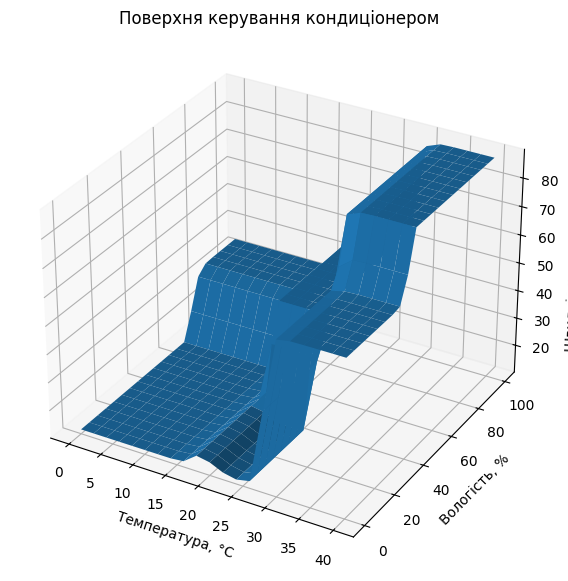

In [35]:
compressor_speed.defuzzify_method = 'centroid'

x_temp = np.arange(0, 41, 2)
y_humidity = np.arange(0, 101, 5)

z_speed = np.zeros((len(y_humidity), len(x_temp)))

for i, hum in enumerate(y_humidity):
    for j, temp in enumerate(x_temp):
        simulation = ctrl.ControlSystemSimulation(air_conditioner_control)
        
        simulation.input['temperature'] = temp
        simulation.input['humidity'] = hum
        simulation.input['people_count'] = 5
        
        simulation.compute()
        
        if 'compressor_speed' in simulation.output:
            z_speed[i, j] = simulation.output['compressor_speed']
        else:
            z_speed[i, j] = np.nan

X, Y = np.meshgrid(x_temp, y_humidity)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, z_speed)

ax.set_xlabel("Температура, °C")
ax.set_ylabel("Вологість, %")
ax.set_zlabel("Швидкість компресора, %")
ax.set_title("Поверхня керування кондиціонером")

plt.show()